In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

DATA_DIR = Path("../data/raw/fashion-dataset")
IMG_DIR = DATA_DIR / "images"
STYLES_CSV = DATA_DIR / "styles.csv"

print("images folder exists:", IMG_DIR.exists())
print("styles csv exists:", STYLES_CSV.exists())

images folder exists: True
styles csv exists: True


In [2]:
# styles.csv has malformed rows in some kaggle versions, hence error_bad_lines fallback
df = pd.read_csv(STYLES_CSV, on_bad_lines='skip')
print("shape:", df.shape)
print("columns:", df.columns.tolist())
df.head()


shape: (44424, 10)
columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [3]:
print("\nmaster categories:")
print(df['masterCategory'].value_counts())
print("\nsub categories (top 15):")
print(df['subCategory'].value_counts().head(15))
print("\narticle types (top 15):")
print(df['articleType'].value_counts().head(15))
print("\nbase colors (top 10):")
print(df['baseColour'].value_counts().head(10))


master categories:
masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64

sub categories (top 15):
subCategory
Topwear       15402
Shoes          7343
Bags           3055
Bottomwear     2694
Watches        2542
Innerwear      1808
Jewellery      1079
Eyewear        1073
Fragrance      1011
Sandal          963
Wallets         933
Flip Flops      913
Belts           811
Socks           698
Lips            527
Name: count, dtype: int64

article types (top 15):
articleType
Tshirts         7067
Shirts          3217
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Kurtas          1844
Tops            1762
Handbags        1759
Heels           1323
Sunglasses      1073
Wallets          936
Flip Flops       914
Sandals          897
Briefs           849
Belts            813
Name: count, dtype: int64

base colors (top 10):
baseCo

In [4]:
df['img_path'] = df['id'].apply(lambda x: IMG_DIR / f"{x}.jpg")
df['img_exists'] = df['img_path'].apply(lambda p: p.exists())
print("total rows:", len(df))
print("images present:", df['img_exists'].sum())
print("missing:", (~df['img_exists']).sum())
df = df[df['img_exists']].reset_index(drop=True)
print("\nafter filtering, shape:", df.shape)

total rows: 44424
images present: 44419
missing: 5

after filtering, shape: (44419, 12)


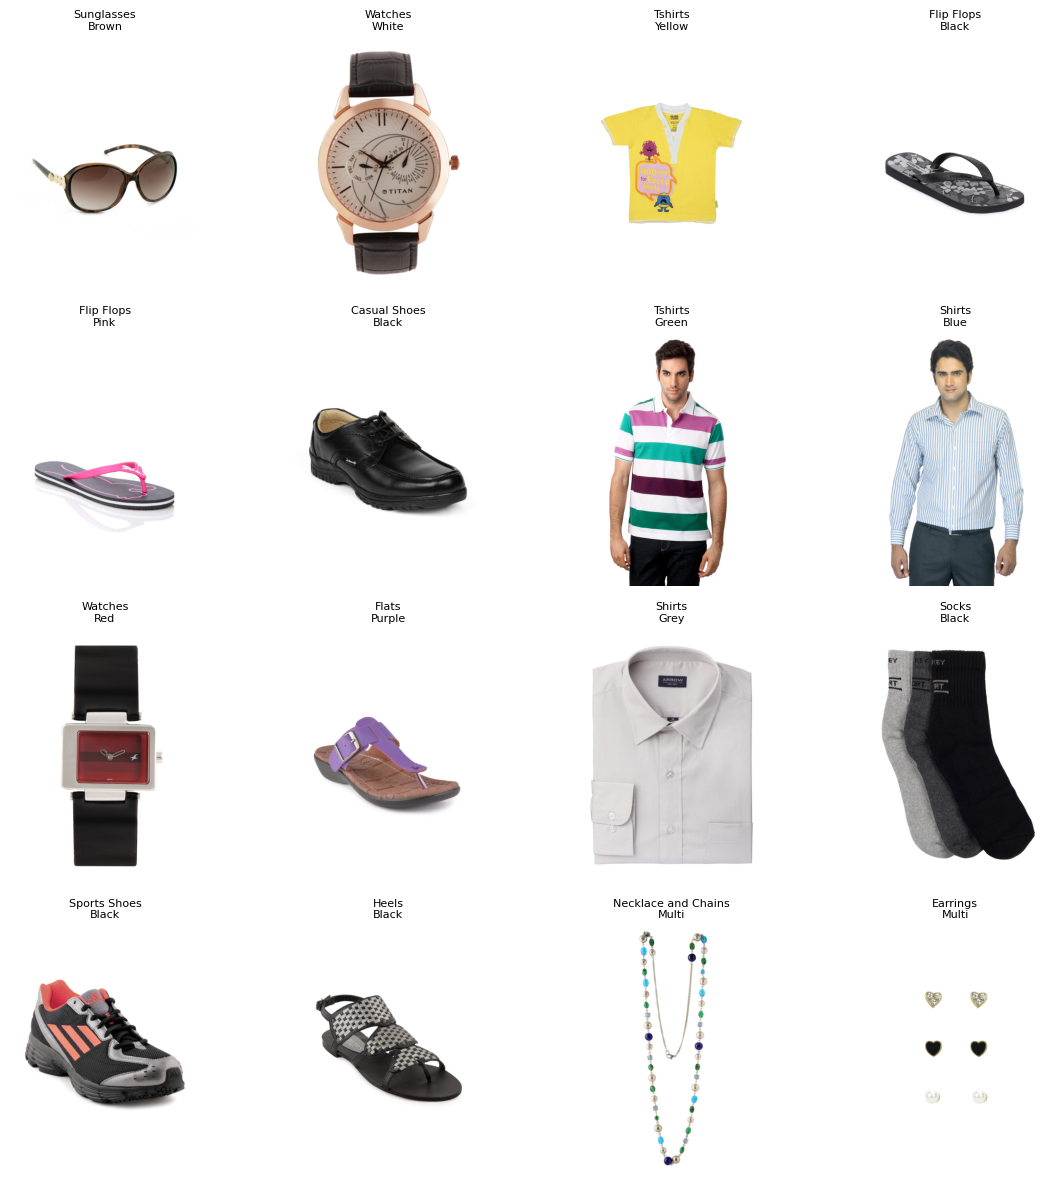

In [5]:
sample = df.sample(16, random_state=42)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img = Image.open(row['img_path'])
    ax.imshow(img)
    ax.set_title(f"{row['articleType']}\n{row['baseColour']}", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
sizes = []
for p in df['img_path'].sample(500, random_state=42):
    with Image.open(p) as im:
        sizes.append(im.size)
sizes = np.array(sizes)
print("width  - min:", sizes[:,0].min(), "max:", sizes[:,0].max(), "mean:", sizes[:,0].mean().round(1))
print("height - min:", sizes[:,1].min(), "max:", sizes[:,1].max(), "mean:", sizes[:,1].mean().round(1))

width  - min: 150 max: 1806 mean: 1399.3
height - min: 200 max: 2700 mean: 1866.3


In [7]:
clean = df[['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']].copy()
clean['img_path'] = clean['id'].apply(lambda x: f"images/{x}.jpg")
clean.to_csv("../data/cached/metadata_clean.csv", index=False)
print("saved", len(clean), "rows to data/cached/metadata_clean.csv")

saved 44419 rows to data/cached/metadata_clean.csv
